# Finetuning

### Cameron Swapp - ORCID: 0009-0004-9019-1097

This notebook takes the SAM2 (segment anything model) produced by META and finetunes it on images of rivers. The end goal is to have a model that can take an image of a river and mask everything except for the river channel. The entire training routine is implemented with validation and test loops shown. New model weights are saved to a file called "sam2_river_masking.pt" which can then be loaded into other files to generate masks onto new images.

Each generated mask contains a .npy file containing the mask itself and a score. The score is the model's prediction of how accurately it masked the river, with score values closer to 1 meaning that the model is more confident that it accurately masked the river.

In [1]:
# These lines need to be run once to download the model and put it in the right place
# After running these once on your machine, the rest of the code will work every time
!mkdir -p ../checkpoints/
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt

--2025-08-17 02:12:31--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.154.144.87, 18.154.144.13, 18.154.144.102, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.154.144.87|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156008466 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘../checkpoints/sam2.1_hiera_tiny.pt.87’

sam2.1_hiera_tiny.p 100%[===================>] 148.78M  97.1MB/s    in 1.5s    

2025-08-17 02:12:33 (97.1 MB/s) - ‘../checkpoints/sam2.1_hiera_tiny.pt.87’ saved [156008466/156008466]



In [2]:
# Import statements - requires torch, numpy, pandas, and pillow in addition to SAM2
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Import and load the SAM2 model (using the tiny version)
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from hydra import initialize
from hydra.core.global_hydra import GlobalHydra

import io
import tarfile

In [3]:
# Required for the program to find the SAM model
GlobalHydra.instance().clear()
initialize(config_path="configs", version_base=None)

hydra.initialize()

In [ ]:
image_dir = "./mask_dataset.tar" # Change './' to the directory where your tar file is located
mask_meta_path = "./river_mask_labels.csv" # Change './' to the directory where your mask label CSV is located

sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt" # Don't change this line,
# the first code chunk makes this work

In [5]:
# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


In [6]:
# Class to convert the data from the tar file into a format that can be used by PyTorch
class RiverMaskDataset(Dataset):
    def __init__(self, tar_path, keys):
        self.tar_path = tar_path
        self.keys = keys

        # Open tar once to build the index of members for fast lookup
        with tarfile.open(self.tar_path, "r") as tar:
            self.member_dict = {m.name: m for m in tar.getmembers()}

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]
        key_img = key + ".jpg"
        key_mask = key + ".npy"

        # Open tarfile inside __getitem__ for multiprocessing safety
        with tarfile.open(self.tar_path, "r") as tar:
            member = self.member_dict[key_img]
            file = tar.extractfile(member)
            image = Image.open(file).convert("RGB")
            image = np.array(image)
            member_mask = self.member_dict[key_mask]
            file = tar.extractfile(member_mask)
            mask = file.read()
            mask = io.BytesIO(mask)
            mask = np.load(mask)
            mask = np.unpackbits(mask, axis=-1)

        # Add a channel dimension to the mask
        mask = mask.reshape(1, mask.shape[0], mask.shape[1])
        return image, mask, key

In [7]:
# Field names come from mask_meta.csv
split_field = "rapid_split"
key_field = "image"

mask_meta = pd.read_csv(mask_meta_path)

# Assign the dataset split based on the metadata
train_idxs = mask_meta.index[mask_meta[split_field] == "train"].to_numpy()
val_idxs = mask_meta.index[mask_meta[split_field] == "val"].to_numpy()
test_idxs = mask_meta.index[mask_meta[split_field] == "test"].to_numpy()

train_keys = mask_meta[key_field].iloc[train_idxs].to_numpy()
val_keys = mask_meta[key_field].iloc[val_idxs].to_numpy()
test_keys = mask_meta[key_field].iloc[test_idxs].to_numpy()

In [8]:
# Split the data into training and testing sets

batch_size = 32

train_dataset = RiverMaskDataset(image_dir, train_keys)
val_dataset = RiverMaskDataset(image_dir, val_keys)
test_dataset = RiverMaskDataset(image_dir, test_keys)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [9]:
# Build the SAM2 model
sam2_model = build_sam2("sam2.1_hiera_t.yaml", sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

predictor.model.sam_mask_decoder.train(True)
predictor.model.sam_prompt_encoder.train(True)

optimizer = optim.Adam(params=sam2_model.parameters(), lr=1e-5)
loss_fn = nn.CrossEntropyLoss()

In [10]:
'''
Function to compute the Intersection over Union (IoU) score
for a ground truth mask and a predicted mask
This function computes the IoU score, which is a common metric
for evaluating the performance of segmentation models
Inputs:
- A ground truth mask
- A predicted mask for the same image
Output: The IoU score of the two masks
'''
def iou_score(mask_true, mask_pred):
    mask_true = mask_true.bool()
    mask_pred = mask_pred > 0.5
    
    intersection = (mask_true & mask_pred).float().sum()
    union = (mask_true | mask_pred).float().sum()
    
    # Edge case where there is no river - the ground truth mask is empty
    if mask_true.float().sum() == 0:
        loss = mask_pred.float().sum() / (mask_pred.shape[0] * mask_pred.shape[1] * mask_pred.shape[2])
        assert loss <= 1.0, "Loss should be less than or equal to 1.0"
        return loss

    if union == 0:
        return torch.tensor(1.0)  # Both empty
    else:
        return intersection / union

In [11]:
'''
Function to process the mask and predicted masks
Inputs:
- A ground truth mask
- A predicted mask for the same image
- Epsilon, a small value included to avoid divide by 0 errors
- The device used for processing (CPU or GPU)
Outputs:
- Processed ground truth mask
- Processed predicted mask
'''
def mask_processing(mask, prd_masks, epsilon, device):
    gt_mask = mask.float().clone().detach().to(device)
    gt_mask = gt_mask.unsqueeze(0)
    prd_mask = torch.sigmoid(prd_masks[:, 0])
    prd_mask = prd_mask.clamp(epsilon, 1 - epsilon)  # Avoid log(0)
    return gt_mask, prd_mask

In [12]:
'''
Function that defines the validation and test loop for the model
Inputs:
- A data loader containing the validation or test data
- unnorm coords, sparse embeddings, and dense embeddings are passed in from the SAM model
- Epsilon, a small value included to avoid divide by 0 errors
Outputs:
- A list of loss scores
- A list of IoU scores
- A list of batch loss scores
'''
def val_test_loop(data_loader, unnorm_coords, sparse_embeddings, dense_embeddings, epsilon):
    losses = []
    ious = []
    for step, (imgs, masks, keys) in enumerate(data_loader):
        batch_n = imgs.size(0)
        batch_loss = []

        for i in range(batch_n):
            img = imgs[i]
            predictor.set_image(img.cpu().numpy())
            img = img.permute(2, 0, 1).to(device)
            mask = masks[i].to(device)

            batched_mode = unnorm_coords.shape[0] > 1
            high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
            low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
                image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
                image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
                repeat_image=batched_mode,
                high_res_features=high_res_features,
            )

            prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

            # Calculate the loss for the segmentation
            gt_mask, prd_mask = mask_processing(mask, prd_masks, epsilon, device)
            seg_loss = (-gt_mask * torch.log(prd_mask) - (1 - gt_mask) * torch.log((1 - prd_mask))).mean()

            # Ensure the masks are in the correct shape
            if gt_mask.ndim == 4:
                gt_mask = gt_mask.squeeze(1)
            if prd_mask.ndim == 4:
                prd_mask = prd_mask.squeeze(1)
            # Calculate the loss for the score
            iou = iou_score(gt_mask, prd_mask)
            ious.append(iou.mean().item())
            score_loss = torch.abs(prd_scores[:, 0] - iou).mean()

            # Combine the two losses, segmentation loss has a much higher weight
            loss = seg_loss + score_loss * 0.1
            losses.append(loss.item())
            batch_loss.append(loss.item())

    return losses, ious, batch_loss

Epoch 1, Train Loss: 0.0166, Validation Loss: 0.4540, Average IoU: 0.1872
Epoch 2, Train Loss: 0.0165, Validation Loss: 0.4515, Average IoU: 0.1890
Epoch 3, Train Loss: 0.0164, Validation Loss: 0.4494, Average IoU: 0.1907
Epoch 4, Train Loss: 0.0163, Validation Loss: 0.4470, Average IoU: 0.1924
Epoch 5, Train Loss: 0.0162, Validation Loss: 0.4452, Average IoU: 0.1940
Epoch 6, Train Loss: 0.0161, Validation Loss: 0.4426, Average IoU: 0.1956
Epoch 7, Train Loss: 0.0160, Validation Loss: 0.4400, Average IoU: 0.1980
Epoch 8, Train Loss: 0.0159, Validation Loss: 0.4390, Average IoU: 0.1994
Epoch 9, Train Loss: 0.0158, Validation Loss: 0.4368, Average IoU: 0.2017
Epoch 10, Train Loss: 0.0158, Validation Loss: 0.4353, Average IoU: 0.2037


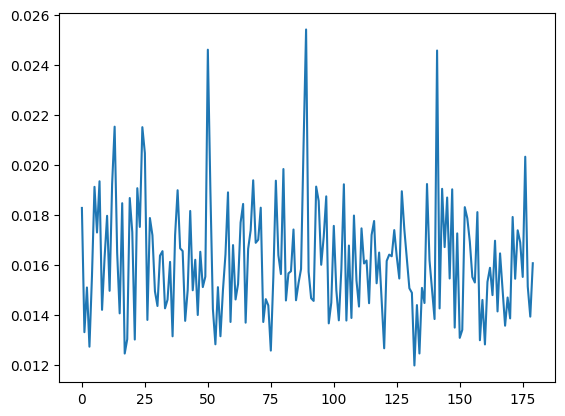

In [ ]:
# Allow the model to predict with no input points
input_point = np.empty((0, 2))
input_label = np.empty((0,), dtype=int)

# Training loop
epsilon = 1e-6
best_iou = -999
patience = 5
num_epochs = 10
batch_losses = []
val_batch_losses = []
for epoch in range(num_epochs):
    sam2_model.train()
    optimizer.zero_grad()
    train_loss = []
    for step, (imgs, masks, keys) in enumerate(train_loader):
        batch_loss = []

        batch_n = imgs.size(0)

        for i in range(batch_n):
            img = imgs[i]
            predictor.set_image(img.cpu().numpy())
            img = img.permute(2, 0, 1).to(device)
            mask = masks[i].to(device)

            mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(input_point, input_label, box=None, mask_logits=None, normalize_coords=True)

            sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
              points=(unnorm_coords, labels), boxes=None, masks=None,
            )

            batched_mode = unnorm_coords.shape[0] > 1
            high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
            low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
                image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
                image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
                repeat_image=batched_mode,
                high_res_features=high_res_features,
            )

            prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

            # Calculate the loss for the segmentation
            gt_mask, prd_mask = mask_processing(mask, prd_masks, epsilon, device)
            seg_loss = (-gt_mask * torch.log(prd_mask) - (1 - gt_mask) * torch.log((1 - prd_mask))).mean()

            # Ensure the masks are in the correct shape
            if gt_mask.ndim == 4:
                gt_mask = gt_mask.squeeze(1)
            if prd_mask.ndim == 4:
                prd_mask = prd_mask.squeeze(1)
            # Calculate the loss for the score
            iou = iou_score(gt_mask, prd_mask)
            score_loss = torch.abs(prd_scores[:, 0] - iou).mean()

            # Combine the two losses, segmentation loss has a much higher weight
            loss = (seg_loss + score_loss * 0.1) / batch_size
            train_loss.append(loss.item())
            batch_loss.append(loss.item())

            loss.backward()

        optimizer.step()
        optimizer.zero_grad()
        batch_losses.append(np.mean(batch_loss))

        val_loss, ious, val_batch_loss = val_test_loop(val_loader, unnorm_coords, sparse_embeddings, dense_embeddings, epsilon)

        val_batch_losses.append(np.mean(val_batch_loss))

    # Implement early stopping based on validation IoU
    if np.mean(ious) > best_iou:
        best_iou = np.mean(ious)
        patience = 5
        torch.save(sam2_model.state_dict(), "./sam2_river_masking.pt"")
    else:
        patience -= 1
        if patience == 0:
            print("Early stopping")
            break   

    print("Epoch %d, Train Loss: %.4f, Validation Loss: %.4f, Average IoU: %.4f" %(epoch+1, np.mean(train_loss).item(), np.mean(val_loss).item(), np.mean(ious).item()))
plt.plot(batch_losses)
plt.show()

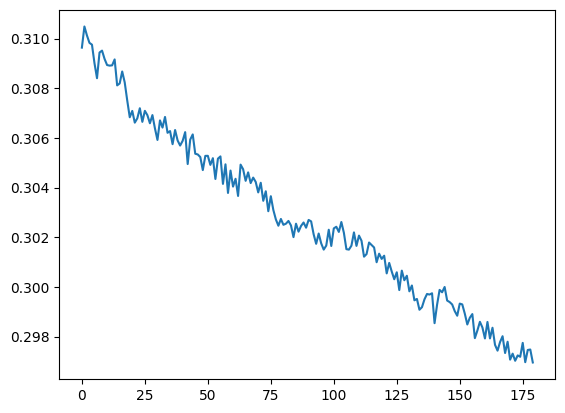

In [14]:
plt.plot(val_batch_losses)
plt.show()

In [15]:
test_loss, ious, test_batch_loss = val_test_loop(val_loader, unnorm_coords, sparse_embeddings, dense_embeddings, epsilon)

print("Test Loss: %.4f, Average IoU: %.4f" %(np.mean(test_loss).item(), np.mean(ious).item()))

Test Loss: 0.4353, Average IoU: 0.2037
